# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

from collections import Counter
import re

# Data Load and Inspect 

In [2]:
df = pd.read_csv("/workspaces/AM2_erp_programme_automataion/data/preprocessed/newsletters_preprocessed.csv")

In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1654 non-null   object 
 1   newsletter_number   1654 non-null   int64  
 2   issue_date          1654 non-null   object 
 3   theme               1654 non-null   object 
 4   subtheme            95 non-null     object 
 5   title               1654 non-null   object 
 6   description         1354 non-null   object 
 7   link                1654 non-null   object 
 8   new_theme           1654 non-null   object 
 9   domain              1643 non-null   object 
 10  organisation        1399 non-null   object 
 11  org_broad_category  1399 non-null   object 
 12  org_category        1399 non-null   object 
 13  item_type           1654 non-null   object 
 14  title_length        1654 non-null   int64  
 15  description_length  1354 non-null   float64
 16  text  

,id,newsletter_number,issue_date,theme,subtheme,title,description,link,new_theme,domain,organisation,org_broad_category,org_category,item_type,title_length,description_length,text,text_length_words
0,a65013c4-ce18-43d8-82a5-b7707d8ecce9,1,11 July 2023,DfE,NaN,"Reject fewer teacher applicants, DfE tells tra...","Susan Acland-Hood, the DfE's permanent secreta...",https://schoolsweek.co.uk/reject-fewer-teacher...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,51,163.0,"Reject fewer teacher applicants, DfE tells tra...",35
1,550a3ffb-c512-4117-b6fa-eff93855fd89,1,11 July 2023,DfE,NaN,Revealed: the experts advising ministers on te...,The Department for Education has appointed an ...,https://schoolsweek.co.uk/revealed-the-experts...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,75,408.0,Revealed: the experts advising ministers on te...,74
2,c79baa9f-775b-444e-bbd4-dc111e4846f4,1,11 July 2023,Calls for evidence,NaN,Deadline 23 August 2023,Education secretary Gillian Keegan has launche...,https://schoolsweek.co.uk/chatgpt-keegan-launc...,policy_practice_research,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,23,174.0,Deadline 23 August 2023 Education secretary Gi...,32
3,9ec40ab1-2d2e-460b-8c82-1ed4a121d770,1,11 July 2023,DfE,NaN,Ofqual and DfE studying 'feasibility' of 'full...,Some exam boards are already piloting on-scree...,https://schoolsweek.co.uk/teachers-back-digita...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,62,254.0,Ofqual and DfE studying 'feasibility' of 'full...,36
4,4776c84a-705e-4c49-aa46-8c759d90540c,1,11 July 2023,What are the politicians saying?,NaN,Labour,Revealed: The full details of Labour's educati...,https://schoolsweek.co.uk/revealed-the-full-de...,political_environment_key_organisations,schoolsweek.co.uk,schools_week,media_sector,specialist_media,news_article,6,232.0,Labour Revealed: The full details of Labour's ...,37


In [4]:
#drop unnecessary columns
cols_to_keep = [  'id', 'newsletter_number', 'issue_date', 'new_theme',
    'organisation', 'org_broad_category', 'org_category',
    'item_type', 'title_length', 'text', 'text_length_words']

df = df[cols_to_keep].copy().rename(columns={'new_theme': 'nl_section'})

In [5]:
df.columns

Index(['id', 'newsletter_number', 'issue_date', 'nl_section', 'organisation',
       'org_broad_category', 'org_category', 'item_type', 'title_length',
       'text', 'text_length_words'],
      dtype='object')

In [6]:
cat_cols = ['nl_section', 'organisation', 'org_broad_category', 'org_category', 'item_type']
df[cat_cols] = df[cat_cols].astype('category')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   id                  1654 non-null   object  
 1   newsletter_number   1654 non-null   int64   
 2   issue_date          1654 non-null   object  
 3   nl_section          1654 non-null   category
 4   organisation        1399 non-null   category
 5   org_broad_category  1399 non-null   category
 6   org_category        1399 non-null   category
 7   item_type           1654 non-null   category
 8   title_length        1654 non-null   int64   
 9   text                1654 non-null   object  
 10  text_length_words   1654 non-null   int64   
dtypes: category(5), int64(3), object(3)
memory usage: 99.5+ KB


In [8]:
# Null counts
df.isnull().sum()

# Value counts for your key categorical fields
for col in ['nl_section', 'org_broad_category', 'item_type']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- nl_section ---
nl_section
political_environment_key_organisations    315
what_matters_ed                            256
teacher_rrd                                233
edtech                                     226
policy_practice_research                   221
four_nations                               165
update_from_pi                             143
update_from_programme                       95
Name: count, dtype: int64

--- org_broad_category ---
org_broad_category
media_sector                             386
government_public_sector                 327
NaN                                      255
academic_sector                          242
knowledge_mobiliser_think_tank_sector    162
civil_society_nonprofit_sector           113
research_evidence_sector                 100
other_miscellaneous                       40
digital_social_media_platforms            15
commercial_private_sector                 14
Name: count, dtype: int64

--- item_type ---
item_type
report         

In [9]:
# issue_date to datetime
df['issue_date'] = pd.to_datetime(df['issue_date'], dayfirst = True, errors='coerce')
print(df['issue_date'].isna().sum())
print(df['issue_date'].min(), df['issue_date'].max())

0
2023-07-11 00:00:00 2026-03-06 00:00:00


# Quality check (number of items per issue)

In [10]:
#issue_size
issue_sizes = df.groupby('newsletter_number').size()
print(issue_sizes.describe())

count    102.000000
mean      16.215686
std        4.440202
min        7.000000
25%       13.000000
50%       16.000000
75%       19.000000
max       30.000000
dtype: float64


In [11]:
issue_sizes[issue_sizes == 7]

newsletter_number
10    7
dtype: int64

# Check TRDD 

In [12]:
rrd = df[df['nl_section'] == 'teacher_rrd']

In [13]:
print(f"teacher_rrd: {len(rrd)} items ({len(rrd)/len(df)*100:.1f}% of corpus)")

teacher_rrd: 233 items (14.1% of corpus)


# Derived variables and lookups

In [39]:
# full_range
full_range = pd.date_range(start='2023-07-01', end='2026-02-01', freq='MS')

# rrd_per_month
rrd_per_month = rrd.groupby(rrd['issue_date'].dt.to_period('M')).size()
rrd_per_month.index = rrd_per_month.index.to_timestamp()
rrd_per_month = rrd_per_month.reindex(full_range, fill_value=0)

# rrd_top15
top15 = ['schools_week', 'nfer', 'uk_government', 'bera', 'epi', 'tes', 'ucl',
         'teacher_tapp', 'uk_parliament', 'bera_journals', 'oecd', 
         'chartered_college_of_teaching', 'conversation', 'eef', 'politics_home']
rrd_top15 = rrd[rrd['organisation'].isin(top15)].copy()
rrd_top15['organisation'] = rrd_top15['organisation'].cat.remove_unused_categories()

# ratio_df
corpus_counts = df['org_broad_category'].value_counts()
rrd_counts = rrd['org_broad_category'].value_counts()
ratio_df = pd.DataFrame({'corpus_n': corpus_counts, 'rrd_n': rrd_counts}).fillna(0)
ratio_df['rrd_ratio'] = ratio_df['rrd_n'] / ratio_df['corpus_n']
ratio_df['corpus_pct'] = ratio_df['corpus_n'] / len(df) * 100
ratio_df['rrd_pct'] = ratio_df['rrd_n'] / len(rrd) * 100

# edtech 
top15_edtech = edtech['organisation'].value_counts().head(15).index.tolist()
edtech_top15 = edtech[edtech['organisation'].isin(top15_edtech)].copy()
edtech_top15['organisation'] = edtech_top15['organisation'].cat.remove_unused_categories()

# Q How many organistions have itms on TRRD 

In [15]:
df['organisation'].nunique()

212

In [16]:
rrd['organisation'].nunique()

42

# Q Top 15 organisations publishing on TRRD 

In [17]:
corpus_org = df['organisation'].value_counts()
rrd_org = rrd['organisation'].value_counts()

ratio_org = pd.DataFrame({
    'corpus_n': corpus_org,
    'rrd_n': rrd_org
}).fillna(0)

ratio_org['rrd_ratio'] = ratio_org['rrd_n'] / ratio_org['corpus_n']
ratio_org['corpus_pct'] = ratio_org['corpus_n'] / len(df) * 100
ratio_org['rrd_pct'] = ratio_org['rrd_n'] / len(rrd) * 100

In [18]:
ratio_org[ratio_org['rrd_n'] > 0].sort_values('rrd_n', ascending=False).head(15)

,corpus_n,rrd_n,rrd_ratio,corpus_pct,rrd_pct
organisation,,,,,
schools_week,180,64,0.355556,10.882709,27.467811
nfer,31,18,0.580645,1.874244,7.725322
uk_government,116,18,0.155172,7.013301,7.725322
bera,43,9,0.209302,2.599758,3.862661
epi,37,8,0.216216,2.237001,3.433476
tes,25,8,0.320000,1.511487,3.433476
ucl,86,7,0.081395,5.199516,3.004292
teacher_tapp,12,6,0.500000,0.725514,2.575107
uk_parliament,58,6,0.103448,3.506651,2.575107


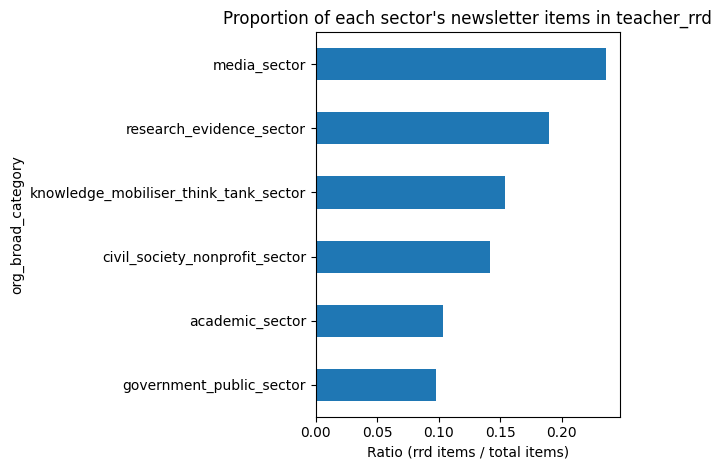

In [19]:
ratio_df[ratio_df['rrd_n'] > 0]['rrd_ratio'].sort_values().plot(
    kind='barh', 
    title='Proportion of each sector\'s newsletter items in teacher_rrd'
)
plt.xlabel('Ratio (rrd items / total items)')
plt.tight_layout()
plt.show()

#### interpretation - Schools Week dominates in volume (64 items, 27% of all teacher_rrd), while NFER and UK Government tie on items (18 each) but NFER punches above its weight with a much higher ratio -- meaning the editorial team drew on NFER far more selectively for recruitment content than it did government sources.
corpus_n -- number of items from that organisation in the whole newsletter corpus (1363 items)
rrd_n -- number of items from that organisation in teacher_rrd (233 items)
rrd_ratio -- rrd_n divided by corpus_n -- what proportion of that organisation's total newsletter items are in teacher_rrd
corpus_pct -- that organisation's share of the whole corpus. Schools Week at 10.9% means they contributed 1 in 10 of all newsletter items
rrd_pct -- that organisation's share of all teacher_rrd items. Schools Week at 27.5% means they contributed more than 1 in 4 of all recruitment items

# Q Relative prominence of teacher_rrd over time 

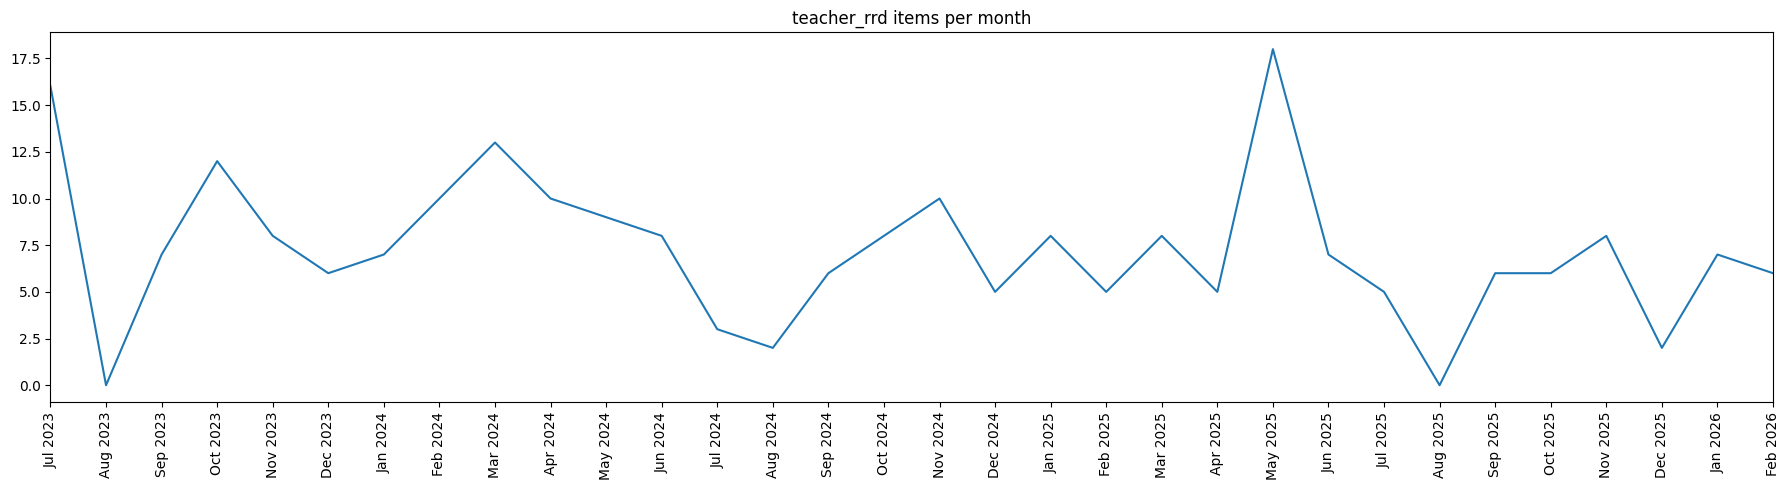

In [20]:
fig, ax = plt.subplots(figsize=(18, 5))
rrd_per_month.plot(kind='line', ax=ax, title='teacher_rrd items per month')
ax.set_xticks(rrd_per_month.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in rrd_per_month.index], rotation=90)
plt.tight_layout()
plt.show()

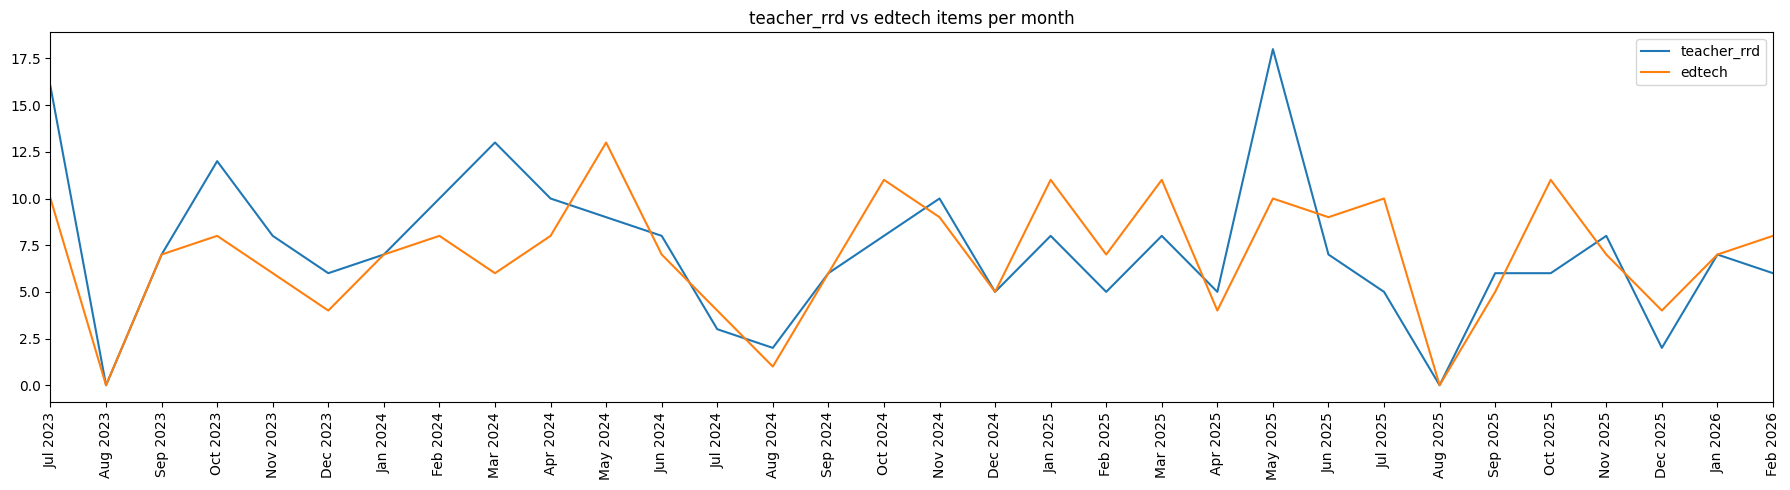

In [21]:
fig, ax = plt.subplots(figsize=(18, 5))

for section in ['teacher_rrd', 'edtech']:
    subset = df[df['nl_section'] == section]
    per_month = subset.groupby(subset['issue_date'].dt.to_period('M')).size()
    per_month.index = per_month.index.to_timestamp()
    per_month = per_month.reindex(full_range, fill_value=0)
    per_month.plot(kind='line', ax=ax, label=section)

ax.set_xticks(full_range)
ax.set_xticklabels([d.strftime('%b %Y') for d in full_range], rotation=90)
ax.legend()
plt.title('teacher_rrd vs edtech items per month')
plt.tight_layout()
plt.show()

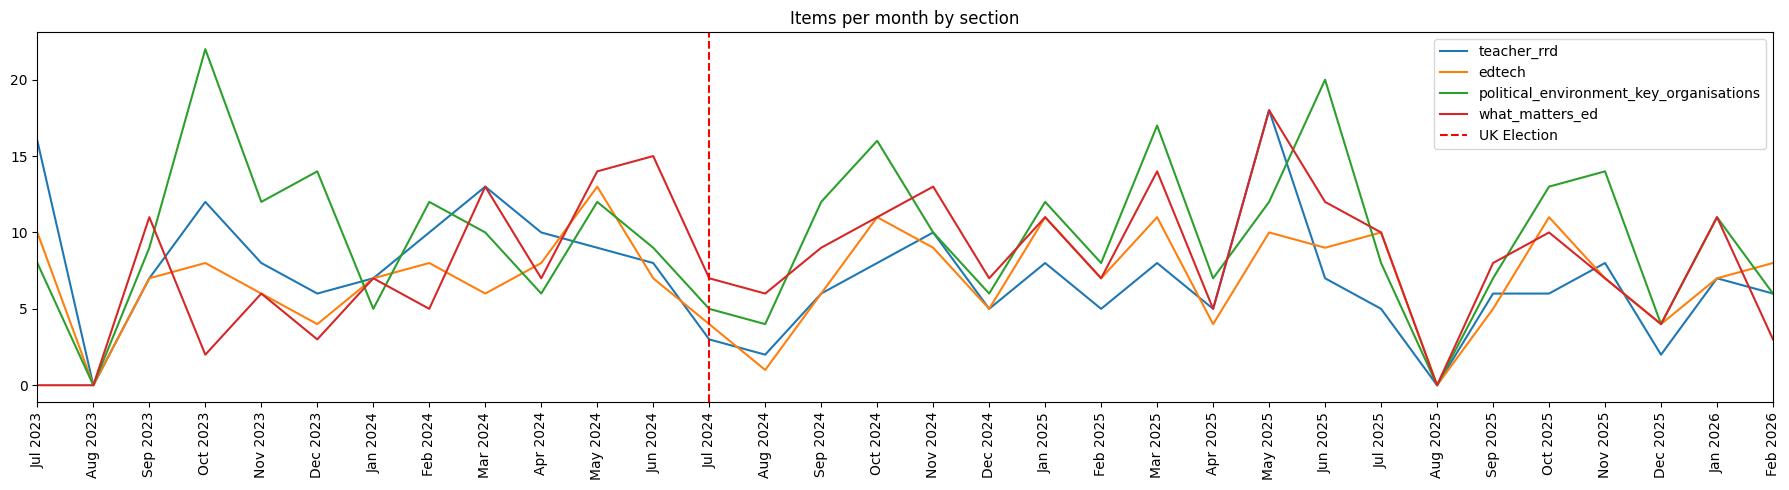

In [22]:
fig, ax = plt.subplots(figsize=(18, 5))

for section in ['teacher_rrd', 'edtech', 'political_environment_key_organisations', 'what_matters_ed']:
    subset = df[df['nl_section'] == section]
    per_month = subset.groupby(subset['issue_date'].dt.to_period('M')).size()
    per_month.index = per_month.index.to_timestamp()
    per_month = per_month.reindex(full_range, fill_value=0)
    per_month.plot(kind='line', ax=ax, label=section)

ax.axvline(pd.Timestamp('2024-07-04'), color='red', linestyle='--', label='UK Election')
ax.set_xticks(full_range)
ax.set_xticklabels([d.strftime('%b %Y') for d in full_range], rotation=90)
ax.legend()
plt.title('Items per month by section')
plt.tight_layout()
plt.show()

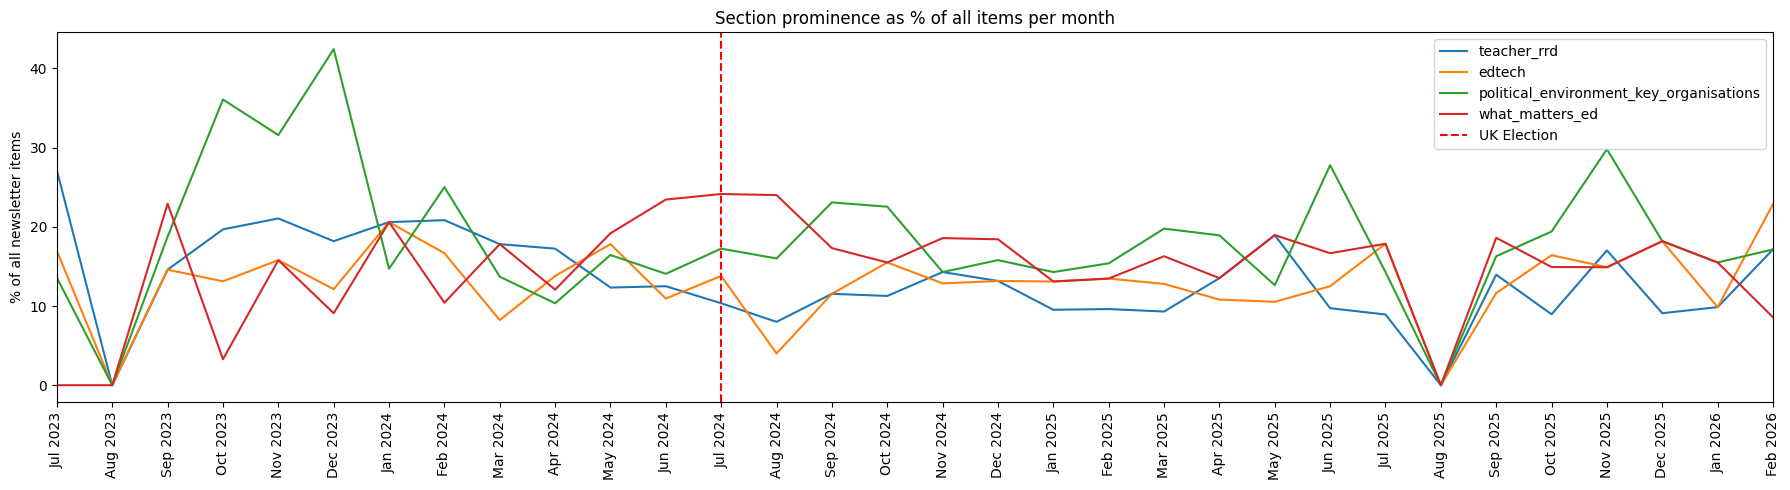

In [23]:
all_per_month = df.groupby(df['issue_date'].dt.to_period('M')).size()
all_per_month.index = all_per_month.index.to_timestamp()
all_per_month = all_per_month.reindex(full_range, fill_value=0)

fig, ax = plt.subplots(figsize=(18, 5))

for section in ['teacher_rrd', 'edtech', 'political_environment_key_organisations', 'what_matters_ed']:
    subset = df[df['nl_section'] == section]
    per_month = subset.groupby(subset['issue_date'].dt.to_period('M')).size()
    per_month.index = per_month.index.to_timestamp()
    per_month = per_month.reindex(full_range, fill_value=0)
    pct = (per_month / all_per_month * 100).fillna(0)
    pct.plot(kind='line', ax=ax, label=section)

ax.axvline(pd.Timestamp('2024-07-04'), color='red', linestyle='--', label='UK Election')
ax.set_xticks(full_range)
ax.set_xticklabels([d.strftime('%b %Y') for d in full_range], rotation=90)
ax.set_ylabel('% of all newsletter items')
ax.legend()
plt.title('Section prominence as % of all items per month')
plt.tight_layout()
plt.show()

# Item type distribution over time 

In [24]:
corpus_item = df['item_type'].value_counts()
rrd_item = rrd['item_type'].value_counts()

item_df = pd.DataFrame({
    'corpus_n': corpus_item,
    'rrd_n': rrd_item
}).fillna(0)

item_df['corpus_pct'] = (item_df['corpus_n'] / len(df) * 100).round(1)
item_df['rrd_pct'] = (item_df['rrd_n'] / len(rrd) * 100).round(1)
item_df['rrd_ratio'] = (item_df['rrd_n'] / item_df['corpus_n']).round(2)
item_df.sort_values('rrd_ratio', ascending=False)

,corpus_n,rrd_n,corpus_pct,rrd_pct,rrd_ratio
item_type,,,,,
news_article,337,87,20.4,37.3,0.26
report,476,74,28.8,31.8,0.16
academic_article,163,16,9.9,6.9,0.10
government_document,271,24,16.4,10.3,0.09
article,297,24,18.0,10.3,0.08
blog_post,95,8,5.7,3.4,0.08
linkedin_post,7,0,0.4,0.0,0.00
tweet,2,0,0.1,0.0,0.00
video,6,0,0.4,0.0,0.00


### Teacher_rrd is disproportionately driven by news articles (37% of recruitment items vs 20% of the full corpus), suggesting recruitment discourse in this curated newsletter is more reactive and event-driven than the newsletter's output overall.

# Keyworods in TRRD 

In [25]:
text = ' '.join(rrd['text'].dropna().tolist()).lower()
words = re.findall(r'\b[a-z]{3,}\b', text)

stopwords = {'the', 'and', 'for', 'that', 'this', 'with', 'are', 'has', 'have', 
             'been', 'its', 'from', 'will', 'their', 'they', 'which', 'more',
             'also', 'but', 'not', 'new', 'was', 'who', 'how', 'what'}

counts = Counter(w for w in words if w not in stopwords)
counts.most_common(10)

[('teacher', 178),
 ('teachers', 157),
 ('schools', 100),
 ('education', 77),
 ('retention', 75),
 ('school', 75),
 ('recruitment', 74),
 ('report', 61),
 ('teaching', 56),
 ('england', 39)]

In [26]:
rrd[rrd['text'].str.contains('thrive', case=False, na=False)][['issue_date', 'text', 'org_broad_category', 'organisation']]

,issue_date,text,org_broad_category,organisation
1169,2025-05-09,The FED event- The Ethics Advantage: Building ...,media_sector,fed
1260,2025-06-13,Event - The OECD teaching Compass: Aligning te...,government_public_sector,oecd
1560,2026-01-23,Department for Education - New training to hel...,NaN,NaN


In [27]:
frames = {
    'supply_pipeline': ['recruitment', 'retention', 'training', 'workforce', 'supply', 
                        'shortage', 'shortages', 'itt', 'recruit', 'trainees', 'trainee', 
                        'graduates', 'providers', 'targets', 'bursaries', 'incentives', 
                        'visa', 'overseas', 'accreditation'],
    'pay_conditions': ['pay', 'workload', 'flexible', 'wellbeing', 'stress', 'burnout', 
                       'mental', 'health', 'pressures', 'costs', 'spending', 'cuts', 
                       'maternity', 'strikes', 'minimum'],
    'professional_development': ['cpd', 'development', 'professional', 'career', 'npqs', 
                                  'npq', 'ecf', 'leadership', 'leaders', 'headteachers', 
                                  'headteacher', 'chartered'],
    'diversity_equity': ['ethnic', 'diversity', 'disadvantaged', 'inclusive', 'communities', 
                         'demographic', 'send', 'pupils', 'children'],
    'political_framing': ['crisis', 'reform', 'targets', 'commission', 'taskforce', 
                          'inquiry', 'election', 'labour', 'dfe', 'committee', 'parliament']
}

people = ['phillipson', 'gibb']

# Frame analysis 

## Q  Which frames dominate overall in teacher_rrd?

In [28]:
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    count = rrd['text'].str.contains(pattern, case=False, na=False).sum()
    print(f"{frame}: {count} items ({count/len(rrd)*100:.1f}%)")

supply_pipeline: 123 items (52.8%)
pay_conditions: 70 items (30.0%)
professional_development: 81 items (34.8%)
diversity_equity: 29 items (12.4%)
political_framing: 88 items (37.8%)


## Q Which sectors use which frames?

In [29]:
frame_sector = {}
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd['text'].str.contains(pattern, case=False, na=False)
    frame_sector[frame] = rrd[mask]['org_broad_category'].value_counts()

frame_sector_df = pd.DataFrame(frame_sector).fillna(0).astype(int)
frame_sector_df

,supply_pipeline,pay_conditions,professional_development,diversity_equity,political_framing
org_broad_category,,,,,
academic_sector,11,4,15,1,6
civil_society_nonprofit_sector,5,6,10,4,1
commercial_private_sector,0,0,0,0,0
digital_social_media_platforms,0,0,0,0,0
government_public_sector,17,8,8,1,17
knowledge_mobiliser_think_tank_sector,11,5,9,1,10
media_sector,50,35,23,10,44
other_miscellaneous,0,0,0,0,0
research_evidence_sector,13,3,6,6,6


## Q. What frames appear alongside Phillipson and Gibb?

In [30]:
for person in people:
    print(f"\n--- {person} ---")
    person_items = rrd[rrd['text'].str.contains(person, case=False, na=False)]
    print(f"{len(person_items)} items mention {person}")
    for frame, keywords in frames.items():
        pattern = '|'.join(keywords)
        count = person_items['text'].str.contains(pattern, case=False, na=False).sum()
        print(f"  {frame}: {count}")


--- phillipson ---
4 items mention phillipson
  supply_pipeline: 1
  pay_conditions: 2
  professional_development: 0
  diversity_equity: 1
  political_framing: 1

--- gibb ---
2 items mention gibb
  supply_pipeline: 2
  pay_conditions: 2
  professional_development: 1
  diversity_equity: 0
  political_framing: 2


## Frame analysis by item type

In [31]:
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd['text'].str.contains(pattern, case=False, na=False)
    print(f"\n--- {frame} ---")
    print(rrd[mask]['item_type'].value_counts())


--- supply_pipeline ---
item_type
news_article           49
report                 33
article                16
government_document    15
academic_article        7
blog_post               3
linkedin_post           0
tweet                   0
video                   0
Name: count, dtype: int64

--- pay_conditions ---
item_type
news_article           33
report                 17
article                 9
government_document     6
blog_post               4
academic_article        1
linkedin_post           0
tweet                   0
video                   0
Name: count, dtype: int64

--- professional_development ---
item_type
report                 31
news_article           22
academic_article        9
article                 9
government_document     8
blog_post               2
linkedin_post           0
tweet                   0
video                   0
Name: count, dtype: int64

--- diversity_equity ---
item_type
report                 12
news_article           10
article            

Supply_pipeline and political_framing are news-dominated -- both have news_article as their top item type by a large margin. These frames are reactive and event-driven, structured by the news cycle.
Professional_development is report-dominated -- reports come first, ahead of news articles. This frame has a slower, more deliberative epistemic texture -- it's being advanced through research outputs rather than news coverage.
Pay_conditions sits in between -- news-heavy but with a meaningful report presence. Both reactive (news) and evidence-based (reports) framings of the problem exist here.
Diversity_equity is striking -- only 29 items total and no academic articles at all. The frame with the most obvious connection to attainment gaps and disadvantaged pupils is the least evidenced academically in this corpus.
Government_document appears most strongly in supply_pipeline (15) and political_framing (16) -- confirming that government sources advance pipeline and political frames, not conditions or professional development frames.

## Frame over time 

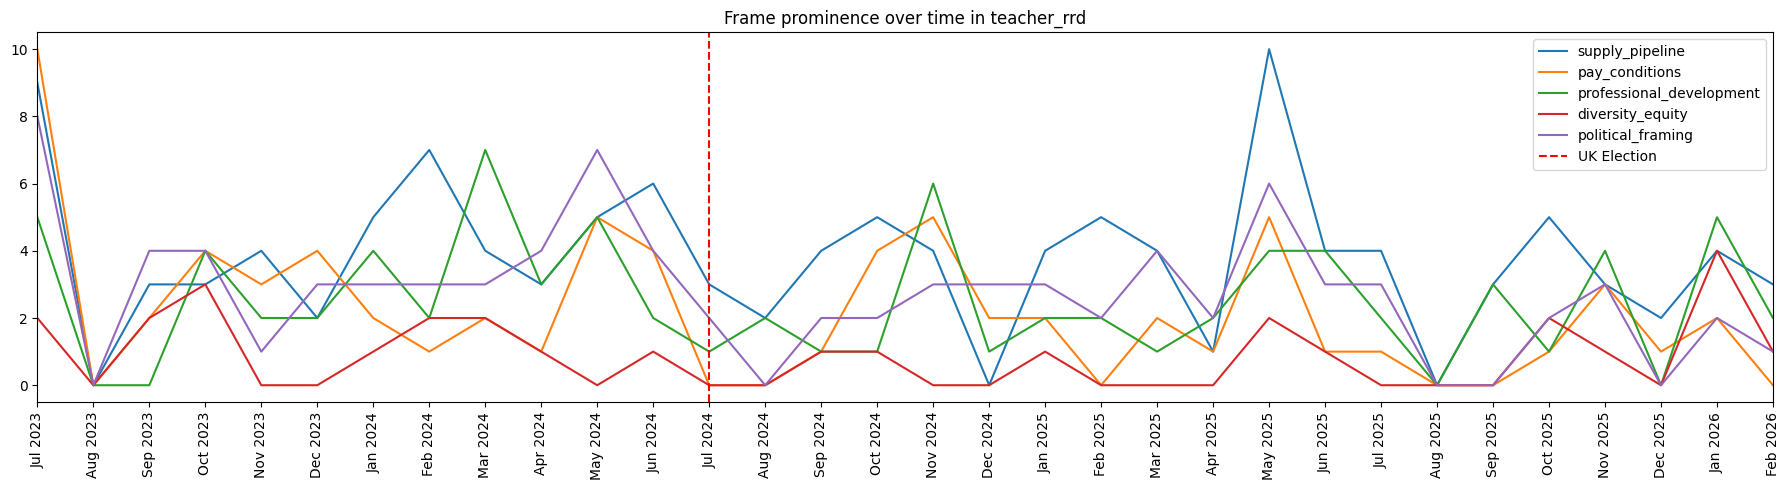

In [32]:
# Frame analysis over time
fig, ax = plt.subplots(figsize=(18, 5))
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd['text'].str.contains(pattern, case=False, na=False)
    subset = rrd[mask]
    per_month = subset.groupby(subset['issue_date'].dt.to_period('M')).size()
    per_month.index = per_month.index.to_timestamp()
    per_month = per_month.reindex(full_range, fill_value=0)
    per_month.plot(kind='line', ax=ax, label=frame)
ax.axvline(pd.Timestamp('2024-07-04'), color='red', linestyle='--', label='UK Election')
ax.set_xticks(full_range)
ax.set_xticklabels([d.strftime('%b %Y') for d in full_range], rotation=90)
ax.legend()
plt.title('Frame prominence over time in teacher_rrd')
plt.tight_layout()
plt.show()

## Frame by top 15 organisation 

In [33]:
org_totals = rrd_top15['organisation'].value_counts()

frame_org_pct = {}
for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    mask = rrd_top15['text'].str.contains(pattern, case=False, na=False)
    counts = rrd_top15[mask]['organisation'].value_counts()
    frame_org_pct[frame] = (counts / org_totals * 100).round(1)

pd.DataFrame(frame_org_pct).fillna(0)


,supply_pipeline,pay_conditions,professional_development,diversity_equity,political_framing
organisation,,,,,
bera,44.4,33.3,66.7,11.1,33.3
bera_journals,40.0,0.0,60.0,0.0,0.0
chartered_college_of_teaching,20.0,0.0,100.0,60.0,0.0
conversation,25.0,50.0,25.0,0.0,50.0
eef,100.0,33.3,0.0,0.0,66.7
epi,37.5,25.0,62.5,12.5,25.0
nfer,72.2,16.7,27.8,33.3,33.3
oecd,0.0,0.0,0.0,0.0,0.0
politics_home,66.7,33.3,0.0,33.3,33.3


**How to read this table:** Each cell shows the percentage of that organisation's teacher_rrd items containing at least one keyword from that frame. Rows do not sum to 100% as a single item can contain keywords from multiple frames.

**Frame distribution by organisation:** Supply_pipeline dominates for NFER (72%), UK Parliament (100%), Politics Home (67%) and Schools Week (58%); professional_development is strong for Chartered College (100%), BERA (67%) and EPI (63%); pay_conditions is notably high for The Conversation (50%) and UK Government (39%); diversity_equity is marginal across almost all organisations -- highest for Chartered College (60%) and TES (38%) -- confirming that the frame most directly connected to disadvantaged pupils is the least engaged with across the corpus.

In [34]:
#top frame for each organsaiton 
pd.DataFrame(frame_org_pct).fillna(0).idxmax(axis=1)

organisation
bera                             professional_development
bera_journals                    professional_development
chartered_college_of_teaching    professional_development
conversation                               pay_conditions
eef                                       supply_pipeline
epi                              professional_development
nfer                                      supply_pipeline
oecd                                      supply_pipeline
politics_home                             supply_pipeline
schools_week                              supply_pipeline
teacher_tapp                            political_framing
tes                                       supply_pipeline
ucl                                       supply_pipeline
uk_government                           political_framing
uk_parliament                             supply_pipeline
dtype: object

**Dominant frame by organisation:** Supply_pipeline is the default frame for media, government and research organisations (Schools Week, NFER, UK Parliament, TES, UCL); professional development dominates for academic and practitioner bodies (BERA, EPI, Chartered College); notably UK Government's dominant frame is political_framing rather than supply_pipeline, and The Conversation leads with pay_conditions -- suggesting different organisational positions produce genuinely different theories of the recruitment problem.

# Co-occurence beside EdTech 

In [35]:
edtech = df[df['nl_section'] == 'edtech']

teacher_adjacent = edtech[edtech['text'].str.contains(
    'teacher|cpd|professional development|staff|workforce', 
    case=False, na=False)]

print(f"{len(teacher_adjacent)} of {len(edtech)} edtech items contain teacher-adjacent terms ({len(teacher_adjacent)/len(edtech)*100:.1f}%)")
teacher_adjacent[['issue_date', 'text', 'org_broad_category', 'organisation']].head(20)

38 of 226 edtech items contain teacher-adjacent terms (16.8%)


,issue_date,text,org_broad_category,organisation
23,2023-07-16,Tony Blair Institute - The Future of Learning:...,knowledge_mobiliser_think_tank_sector,tony_blair_institute
89,2023-09-08,Artificial intelligence (AI) is still unsuitab...,media_sector,tes
113,2023-10-19,AI in schools now Oriel Square report on Gener...,commercial_private_sector,oriel_square
174,2023-11-03,New support for teachers powered by Artificial...,government_public_sector,uk_government
213,2023-12-01,The inexorable rise of AI Teacher Tapp Blog Re...,knowledge_mobiliser_think_tank_sector,teacher_tapp
259,2024-01-19,Artificial Incentives: Will students feel moti...,media_sector,rebecca_allen
266,2024-01-26,Five changes experts suggest on AI in schools ...,media_sector,schools_week
276,2024-02-05,Tech4Teachers White paper The digital poverty ...,civil_society_nonprofit_sector,digital_poverty_alliance
434,2024-04-26,DfE Roundtable - Deputy Prime Minister and Edu...,government_public_sector,uk_government
523,2024-05-24,Schools Week - Ministers plan to appoint edtec...,media_sector,schools_week


**EdTech adjacency:** 38 of 226 edtech items (16.8%) contain teacher-adjacent terms, spread across media, government, academic and think tank sources. The content splits into two distinct theories of teacher development: AI as a productivity tool for teachers (lesson preparation, workload reduction -- DfE, Teacher Tapp, Schools Week) and AI as a professional development resource (CPD, digital capital -- NFER, BERA). Both sit in the edtech category and would be invisible to any analysis of teacher_rrd in isolation -- the curatorial boundary between edtech and teacher_rrd is itself a classification decision that separates technological and professional framings of the same underlying question.

# EDtech frame anlaysis 

In [36]:
edtech_text = ' '.join(edtech['text'].dropna().tolist()).lower()
edtech_words = re.findall(r'\b[a-z]{3,}\b', edtech_text)
edtech_counts = Counter(w for w in edtech_words if w not in stopwords)
edtech_counts.most_common(10)

[('education', 187),
 ('digital', 103),
 ('schools', 95),
 ('children', 85),
 ('research', 59),
 ('use', 51),
 ('can', 49),
 ('report', 47),
 ('here', 46),
 ('government', 37)]

In [37]:
edtech_frames = {
    'ai_tools': ['artificial', 'intelligence', 'generative', 'chatgpt', 'genai', 
                 'tools', 'technology', 'technologies', 'tech', 'digital', 'platforms',
                 'personalised', 'marking', 'automation'],
    
    'phones_safety': ['phones', 'phone', 'smartphones', 'smartphone', 'mobile', 
                      'ban', 'bans', 'online', 'internet', 'screen', 'offline',
                      'safety', 'risks', 'vulnerabilities', 'protection'],
    
    'equity_access': ['disadvantaged', 'divide', 'poverty', 'equity', 'inclusion',
                      'inclusive', 'access', 'send', 'special', 'ehcps', 'families',
                      'communities', 'race', 'whiteness'],
    
    'governance_regulation': ['regulation', 'governance', 'ethics', 'ethical', 
                               'rights', 'statutory', 'guidance', 'consultation',
                               'inquiry', 'committee', 'parliament', 'bill',
                               'standards', 'responsibility'],
    
    'learning_outcomes': ['learning', 'assessment', 'curriculum', 'outcomes',
                          'evidence', 'impact', 'evaluation', 'literacy',
                          'skills', 'feedback', 'classroom', 'teaching'],
    
    'teacher_development': ['teacher', 'teachers', 'cpd', 'professional', 
                             'workforce', 'training', 'development', 'leadership',
                             'educators', 'wellbeing', 'workload', 'lesson']
}

In [40]:
edtech_org_totals = edtech_top15['organisation'].value_counts()
edtech_frame_org_pct = {}
for frame, keywords in edtech_frames.items():
    pattern = '|'.join(keywords)
    mask = edtech_top15['text'].str.contains(pattern, case=False, na=False)
    counts = edtech_top15[mask]['organisation'].value_counts()
    edtech_frame_org_pct[frame] = (counts / edtech_org_totals * 100).round(1)

pd.DataFrame(edtech_frame_org_pct).fillna(0)

,ai_tools,phones_safety,equity_access,governance_regulation,learning_outcomes,teacher_development
organisation,,,,,,
5rights_foundation,66.7,83.3,16.7,100.0,0.0,0.0
bera,60.0,20.0,0.0,20.0,40.0,40.0
chartered_college_of_teaching,100.0,40.0,20.0,20.0,100.0,60.0
childrens_commissioner,0.0,100.0,0.0,0.0,33.3,0.0
conversation,50.0,50.0,0.0,50.0,0.0,50.0
digital_poverty_alliance,100.0,0.0,100.0,0.0,33.3,33.3
guardian,20.0,80.0,10.0,20.0,20.0,10.0
london_school_of_economics,100.0,66.7,0.0,100.0,33.3,0.0
national_education_union,33.3,0.0,0.0,0.0,33.3,33.3


**Edtech frame distribution by organisation:** AI_tools dominates for most organisations -- DfE (76%), Chartered College (100%), Digital Poverty Alliance (100%), Nuffield (75%) and UCL (75%) all lead with it, reflecting how thoroughly AI has colonised the edtech agenda. Phones_safety is the dominant concern for Children's Commissioner (100%), Guardian (80%) and 5Rights Foundation (83%) -- a completely different theory of the technology problem focused on harm rather than opportunity. UK Parliament splits between governance_regulation (75%) and phones_safety (67%), suggesting parliamentary attention to edtech is primarily regulatory. Teacher_development is notably low across almost all organisations -- highest for Nuffield (75%) and UK Parliament (58%) -- confirming that even within edtech, teacher professional development is a marginal concern. The contrast with teacher_rrd is stark: organisations that dominate recruitment discourse (NFER, Schools Week) are largely absent from edtech, and vice versa -- these are genuinely separate organisational communities discussing separate theories of the education technology problem.

In [ ]:
pd.DataFrame(edtech_frame_org_pct).fillna(0).idxmax(axis=1)

**Dominant edtech frame by organisation:** AI_tools dominates for 11 of 15 organisations -- spanning media (Schools Week), government (DfE), academic (UCL, LSE, BERA), think tanks (Nuffield, Ada Lovelace) and practitioner bodies (Chartered College) -- suggesting near-universal framing of edtech as an AI question. The two exceptions are telling: 5Rights Foundation and UK Parliament lead with governance_regulation, and Children's Commissioner and Guardian lead with phones_safety. These three organisations represent a harm-and-rights counter-narrative to the dominant opportunity framing -- but they are a minority. Teacher_development does not dominate for any organisation, confirming that even bodies like Chartered College frame edtech primarily as an AI tool question rather than a professional development question.

## Attainement gap ins in teacher_rrd

In [41]:
attainment_keywords = ['disadvantaged', 'attainment gap', 'pupil premium', 
                       'deprivation', 'socioeconomic', 'equity', 'social mobility',
                       'poverty', 'closing the gap', 'achievement gap']

pattern = '|'.join(attainment_keywords)
attainment_items = rrd[rrd['text'].str.contains(pattern, case=False, na=False)]

print(f"{len(attainment_items)} of {len(rrd)} teacher_rrd items mention attainment/disadvantage ({len(attainment_items)/len(rrd)*100:.1f}%)")
attainment_items[['issue_date', 'text', 'org_broad_category', 'organisation']]

7 of 233 teacher_rrd items mention attainment/disadvantage (3.0%)


,issue_date,text,org_broad_category,organisation
84,2023-09-08,Retaining high-quality teachers in disadvantag...,media_sector,tes
87,2023-09-08,Millions Of GCSE Lessons Taught By Non-Special...,media_sector,politics_home
325,2024-03-01,Report from EEF - Teacher recruitment and rete...,NaN,NaN
621,2024-08-01,WomenEd with BAMEedNetwork and HeadTeachers' R...,NaN,NaN
1543,2026-01-16,BERA - Event: Teacher recruitment and retentio...,academic_sector,bera
1637,2026-02-27,The Chartered College of Teaching - How to ret...,civil_society_nonprofit_sector,chartered_college_of_teaching
1645,2026-03-06,"Department for Education - 6,500 additional te...",government_public_sector,uk_government


In [42]:
attainment_items[['issue_date', 'text', 'org_broad_category', 'organisation']]

,issue_date,text,org_broad_category,organisation
84,2023-09-08,Retaining high-quality teachers in disadvantag...,media_sector,tes
87,2023-09-08,Millions Of GCSE Lessons Taught By Non-Special...,media_sector,politics_home
325,2024-03-01,Report from EEF - Teacher recruitment and rete...,NaN,NaN
621,2024-08-01,WomenEd with BAMEedNetwork and HeadTeachers' R...,NaN,NaN
1543,2026-01-16,BERA - Event: Teacher recruitment and retentio...,academic_sector,bera
1637,2026-02-27,The Chartered College of Teaching - How to ret...,civil_society_nonprofit_sector,chartered_college_of_teaching
1645,2026-03-06,"Department for Education - 6,500 additional te...",government_public_sector,uk_government


**The attainment gap link is almost absent:** Only 7 of 233 teacher_rrd items (3%) explicitly connect recruitment to disadvantage or attainment. Of those 7, two are from media (TES, Politics Home) in September 2023, one from EEF (2024), one from a diversity network (WomenEd/BAMEed, 2024), and three cluster in early 2026 (BERA, Chartered College, DfE). Two items have no organisation recorded. The DfE item -- 6,500 additional teachers targeted at disadvantaged areas -- is the only government source to make the link explicit, and it appears in March 2026, nearly three years into the newsletter's run. The connection between teacher recruitment and the pupils recruitment policy is supposed to serve is not absent from this corpus because it was never raised -- it is absent because the editorial and organisational framing of recruitment as a supply problem systematically crowds it out.

# 4 nations

In [49]:
pre = rrd[rrd['issue_date'] < '2024-07-04']
post = rrd[rrd['issue_date'] >= '2024-07-04']

print(f"Pre-election: {len(pre)} items | Post-election: {len(post)} items\n")

for frame, keywords in frames.items():
    pattern = '|'.join(keywords)
    pre_pct = pre['text'].str.contains(pattern, case=False, na=False).sum() / len(pre) * 100
    post_pct = post['text'].str.contains(pattern, case=False, na=False).sum() / len(post) * 100
    diff = post_pct - pre_pct
    print(f"{frame}: pre {pre_pct:.1f}% → post {post_pct:.1f}% (change: {diff:+.1f}%)")

Pre-election: 106 items | Post-election: 127 items

supply_pipeline: pre 48.1% → post 56.7% (change: +8.6%)
pay_conditions: pre 35.8% → post 25.2% (change: -10.7%)
professional_development: pre 34.0% → post 35.4% (change: +1.5%)
diversity_equity: pre 13.2% → post 11.8% (change: -1.4%)
political_framing: pre 41.5% → post 34.6% (change: -6.9%)
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


**Post-election frame shift:** After July 2024, supply_pipeline strengthens (+8.6%) while pay_conditions drops sharply (-10.7%) and political_framing falls (-6.9%). This is counterintuitive -- you might expect a new government to generate more political framing, but the opposite happened. The most likely explanation is that the pre-election period was dominated by Labour's policy promises and teacher pay disputes (strikes, pay review), which inflated both political_framing and pay_conditions before the election. Post-election, with Labour in power and the immediate pay dispute resolved, discourse shifted back to the default supply/pipeline frame. Professional_development and diversity_equity barely move across either period -- confirming these are structurally marginal frames regardless of the political context, not just cyclical responses to events.

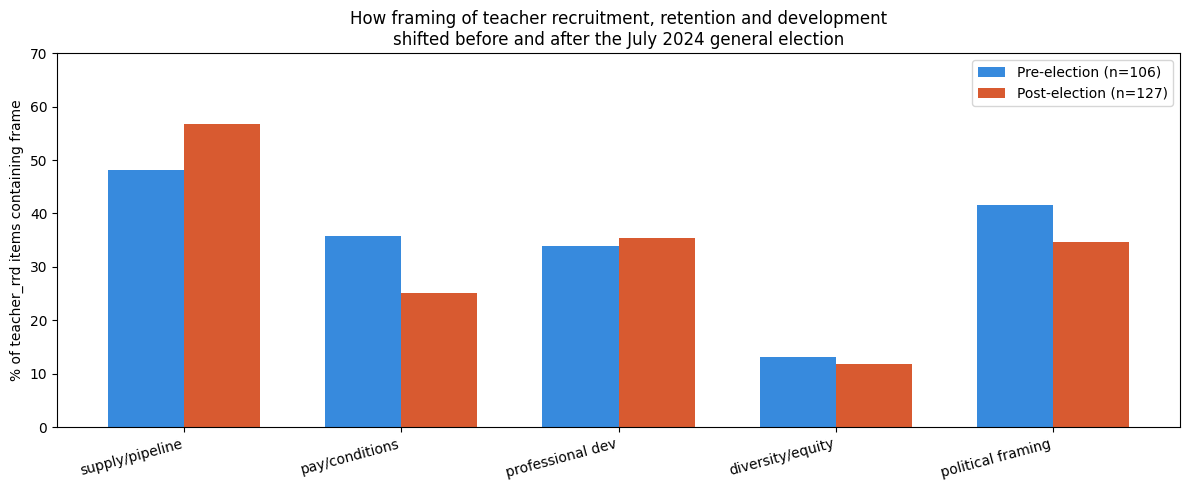

In [51]:
labels = ['supply/pipeline', 'pay/conditions', 'professional dev', 'diversity/equity', 'political framing']
pre = [48.1, 35.8, 34.0, 13.2, 41.5]
post = [56.7, 25.2, 35.4, 11.8, 34.6]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, pre, width, label='Pre-election (n=106)', color='#378ADD')
ax.bar(x + width/2, post, width, label='Post-election (n=127)', color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('% of teacher_rrd items containing frame')
ax.set_title('How framing of teacher recruitment, retention and development\nshifted before and after the July 2024 general election')
ax.legend()
ax.set_ylim(0, 70)
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()